In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from hgnn.Modules_zinb import log_zinb_positive
from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from sklearn.preprocessing import MinMaxScaler

In [26]:
from examples.case_studies.PEA_STA_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [27]:
len(labels)

210

In [28]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(np.abs(data) < 1e-5, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [29]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 141
After remove all nan 88
After remove all zeros 76
Input #cols 141
After remove all nan 78
After remove all zeros 77


Text(0.5, 1.0, 'methylation_data_clean')

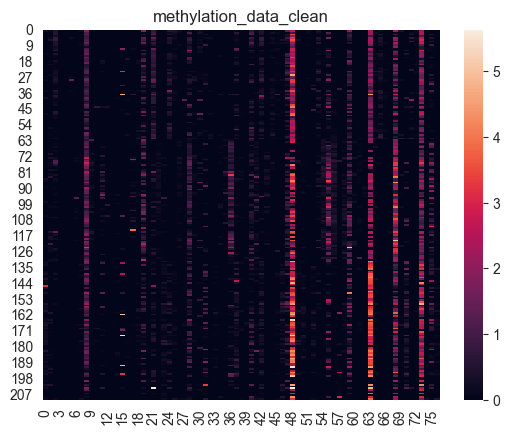

In [30]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

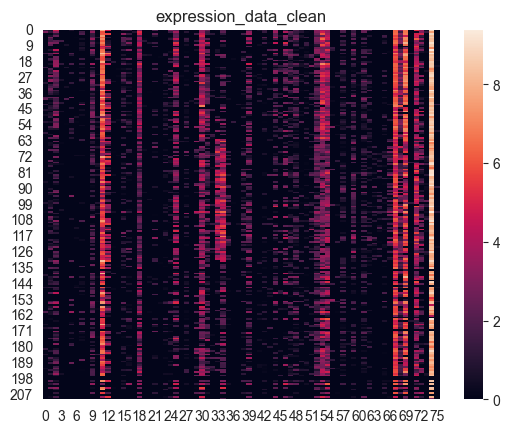

In [31]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [32]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [33]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [34]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((5536, 3), (5536,), (4440, 3), (4440,))

In [35]:
expression_edges.max(0), methylation_edges.max(0)

(array([209,  75,   0]), array([209, 152,   1]))

In [36]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [37]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [38]:
edges.shape, weights.shape

((9976, 3), (9976,))

In [39]:
weights.min(), weights.max()

(np.float64(0.001), np.float64(9.391))

In [40]:
np.any(np.abs(weights) < 1e-5)

np.False_

In [41]:
save_edges_and_weights('./data/PEA_STA', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [42]:
train_data = np.load('./data/PEA_STA/train_data.npz', allow_pickle=True)
test_data = np.load('./data/PEA_STA/test_data.npz', allow_pickle=True)

In [43]:
train_data['train_weight'].shape

(9976,)

In [44]:
np.any(np.any(train_data['train_weight'] < 1e-5))

np.False_

In [45]:
train_data['nums_type']

array([210, 153,   2])

In [46]:
!mkdir -p ./embeddings/hgnn/PEA_STA

In [67]:
!python3 hgnn/main_torch_zinb.py --data PEA_STA --feature adj --loss zinb --iter 50 && mv ./*.npy ./embeddings/hgnn/PEA_STA

1.0 -0.5
model_no_randomwalk
Use train_weight (9976,)
Node type num [210 153   2]
embeddings_initial [np.False_, np.False_, np.False_]
[1.179 0.741 4.785 ... 1.606 0.339 0.517] 0.001 9.391
walk type 
adding pad idx
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
dict_size 9976 9976
train data amount 9976
64
tensor([  0, 210, 363, 365], device='mps:0')
w.shape (210, 155)
(210, 155)
w.shape (153, 212)
(153, 212)
w.shape (2, 363)
(2, 363)
self.input_size [155, 212, 363]
inp 155 out 64 weight.shape torch.Size([64, 155])
fan_in 155 12.449899597988733
inp 212 out 64 weight.shape torch.Size([64, 212])
fan_in 212 14.560219778561036
inp 363 out 64 weight.shape torch.Size([64, 363])
fan_in 363 19.05255888325765
params to be trained 134609
batch size 96
[ Epoch 0 of 50 ]
  - (Training)   bce:  0.7178, skipgram:  0.0000, recon:  0.4644 acc: 0.610 %, pearson: 0.509, sp

## Analysis

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from torch.optim import Adam
import torch.nn.functional as F
import torch
from hgnn.phasing import *

In [69]:
cell_embeddings = np.load('./embeddings/hgnn/PEA_STA/mymodel_0.npy', allow_pickle=True)
gene_embeddings = np.load('./embeddings/hgnn/PEA_STA/mymodel_1.npy', allow_pickle=True)
omic_embeddings = np.load('./embeddings/hgnn/PEA_STA/mymodel_2.npy', allow_pickle=True)


In [70]:
cell_embeddings.shape

(210, 64)

{'NMI': 0.6716415462451144,
 'ARI': 0.5363745847512826,
 'FMI': 0.7317986458523952}

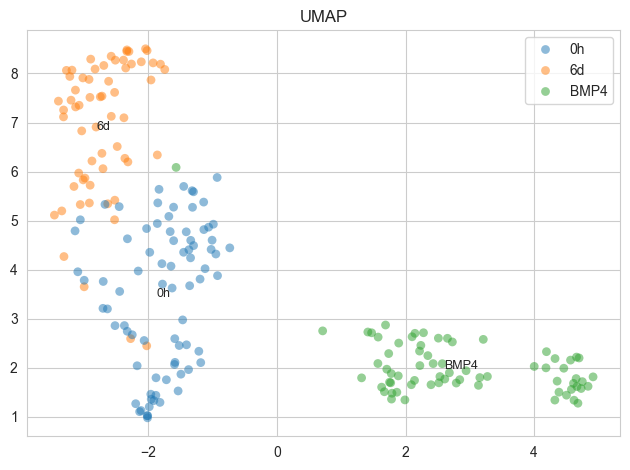

In [71]:
umap_visualize(cell_embeddings, labels)

## Phasing

In [72]:
G = torch.tensor(gene_embeddings, dtype=torch.float)
C = torch.tensor(cell_embeddings, dtype=torch.float)
O = torch.tensor(omic_embeddings, dtype=torch.float)
X_np = np.concatenate([expression_data_clean, methylation_data_clean], axis=1)
X_np = MinMaxScaler().fit_transform(X_np)
X = torch.tensor(X_np, dtype=torch.float)

In [73]:
epochs = 2000
embed_dim = C.shape[1]
# 超参，按需要调
alpha = 0.001
k = 3
lr = 1e-3
omics_offset = expression_data_clean.shape[1]
num_cells = C.shape[0]
num_genes = G.shape[0]
embed_dim, omics_offset

(64, 76)

In [75]:
model, histories = train_phasing_model(
    embed_dim=embed_dim,
    omics_offset=omics_offset,
    epochs=epochs,
    lr=lr,
    k=k,
    alpha=alpha,
    activations=[F.relu, F.relu],
    C=C, G=G, O=O, X=X,
)

Epoch   0  total=1180.166  rec=198.061  reg=982104.688
Epoch 100  total=2.641  rec=0.300  reg=2341.567
Epoch 200  total=0.687  rec=0.168  reg=519.448
Epoch 300  total=0.314  rec=0.145  reg=168.287
Epoch 400  total=0.205  rec=0.139  reg=65.496
Epoch 500  total=0.167  rec=0.137  reg=29.439
Epoch 600  total=0.150  rec=0.136  reg=14.118
Epoch 700  total=0.143  rec=0.136  reg=7.090
Epoch 800  total=0.139  rec=0.136  reg=3.627
Epoch 900  total=0.137  rec=0.136  reg=1.819
Epoch 1000  total=0.136  rec=0.136  reg=0.885
Epoch 1100  total=0.136  rec=0.136  reg=0.417
Epoch 1200  total=0.136  rec=0.136  reg=0.190
Epoch 1300  total=0.136  rec=0.136  reg=0.085
Epoch 1400  total=0.136  rec=0.136  reg=0.039
Epoch 1500  total=0.136  rec=0.136  reg=0.020
Epoch 1600  total=0.136  rec=0.136  reg=0.013
Epoch 1700  total=0.136  rec=0.136  reg=0.010
Epoch 1800  total=0.136  rec=0.136  reg=0.009
Epoch 1900  total=0.136  rec=0.136  reg=0.009


Text(0.5, 1.0, 'Phasing Loss vs Epoch')

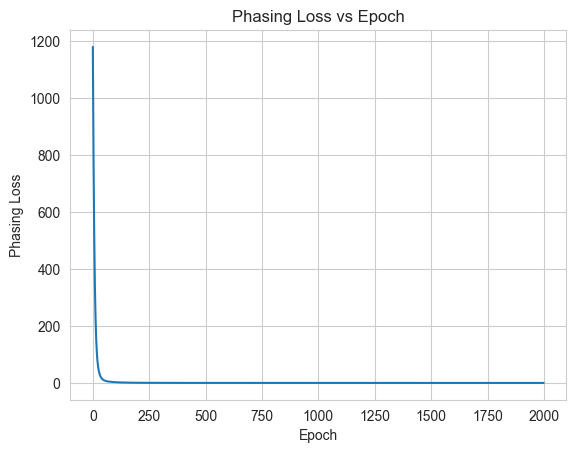

In [76]:
plt.plot(histories['history'])
plt.xlabel('Epoch')
plt.ylabel('Phasing Loss')
plt.title('Phasing Loss vs Epoch')

Text(0.5, 1.0, 'Reconstruction Loss vs Epoch')

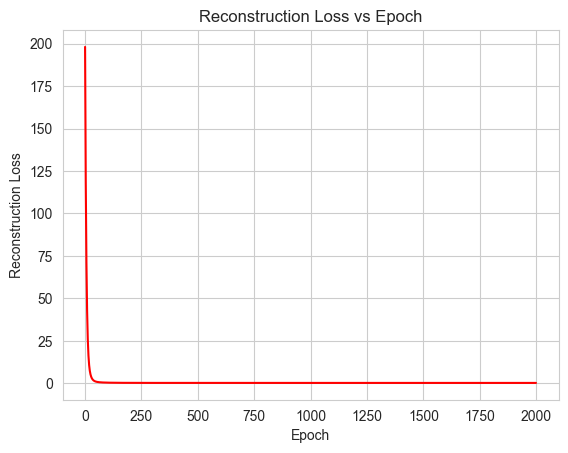

In [77]:
plt.plot(histories['history_recon'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Reconstruction Loss vs Epoch')

Text(0.5, 1.0, 'Regularization Loss vs Epoch')

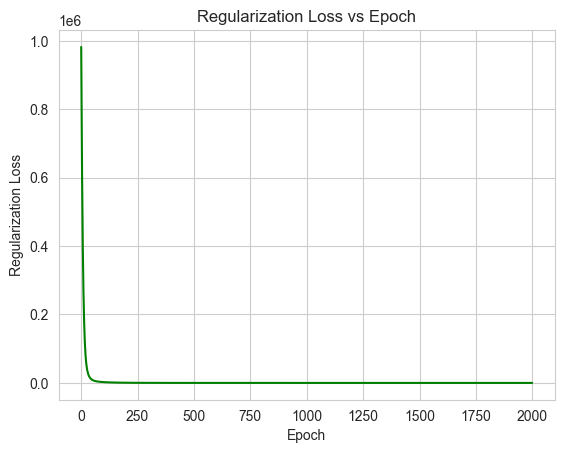

In [78]:
plt.plot(histories['history_reg'], color='green')
plt.xlabel('Epoch')
plt.ylabel('Regularization Loss')
plt.title('Regularization Loss vs Epoch')

In [79]:
Xp0, Xp1, Xm0, Xm1 = model.predict(G, C, O)

In [80]:
np.all(Xp0 < 1), np.all(Xp1 < 1), np.all(Xm0 < 1), np.all(Xm1 < 1)

(np.True_, np.True_, np.True_, np.True_)

In [81]:
X.min(), X.max()

(tensor(0.), tensor(1.))

Text(0.5, 1.0, 'X1')

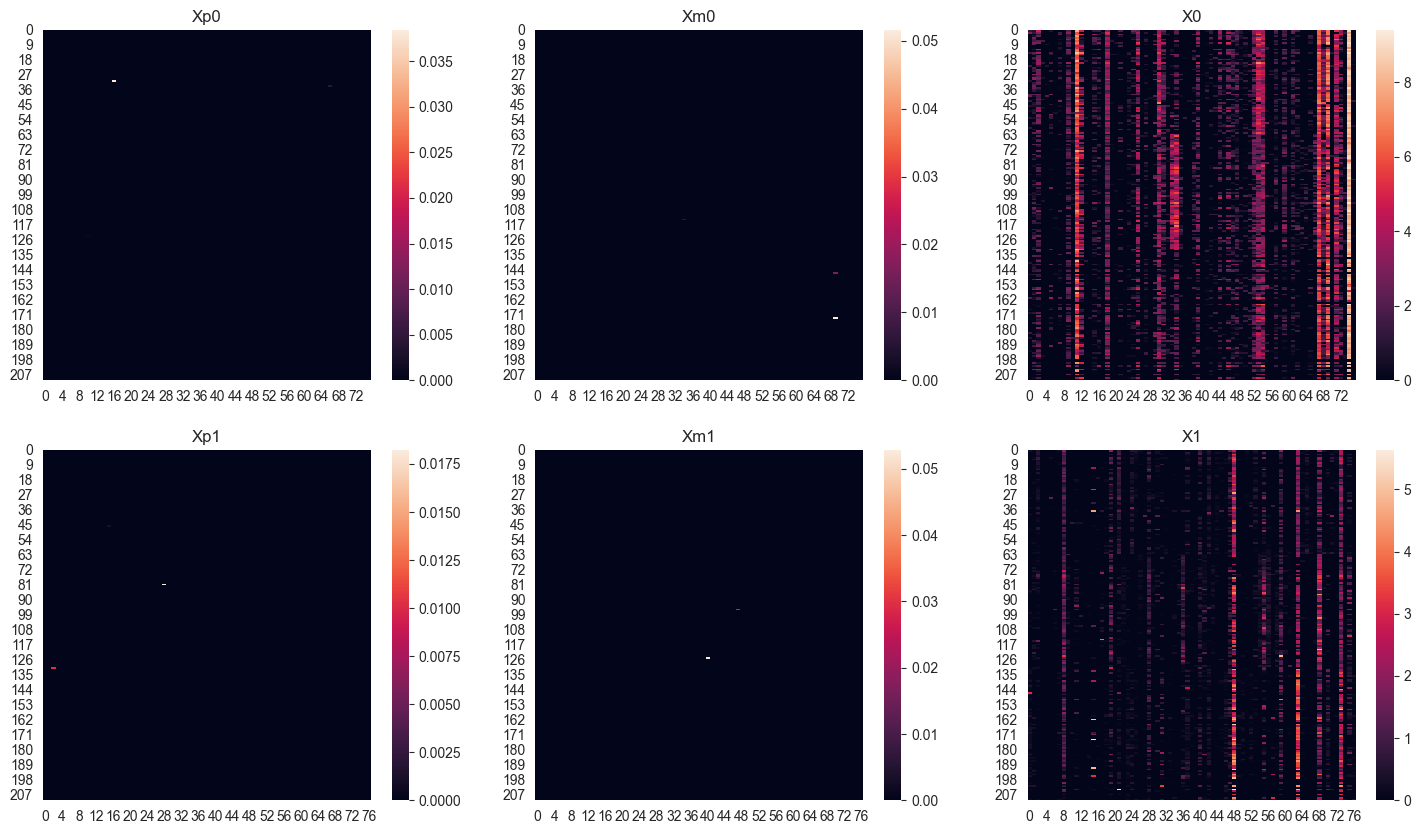

In [82]:
plt.figure(figsize=(18,10))
ax = plt.subplot(231)
sns.heatmap(Xp0,ax=ax)
plt.title('Xp0')
ax = plt.subplot(232)
sns.heatmap(Xm0,ax=ax)
plt.title('Xm0')
ax = plt.subplot(233)
sns.heatmap(expression_data_clean,ax=ax)
plt.title('X0')
ax = plt.subplot(234)
sns.heatmap(Xp1,ax=ax)
plt.title('Xp1')
ax = plt.subplot(235)
sns.heatmap(Xm1,ax=ax)
plt.title('Xm1')
ax = plt.subplot(236)
sns.heatmap(methylation_data_clean,ax=ax)
plt.title('X1')

{'NMI': 0.020325562839047157,
 'ARI': 0.0024926648335882448,
 'FMI': 0.5733944139917748}

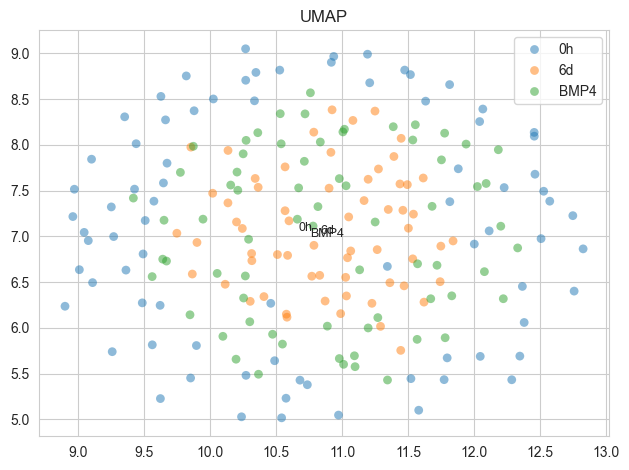

In [83]:
umap_visualize(Xp0, labels)

{'NMI': 0.01853244929890103,
 'ARI': 0.000560046138275518,
 'FMI': 0.5722790156597081}

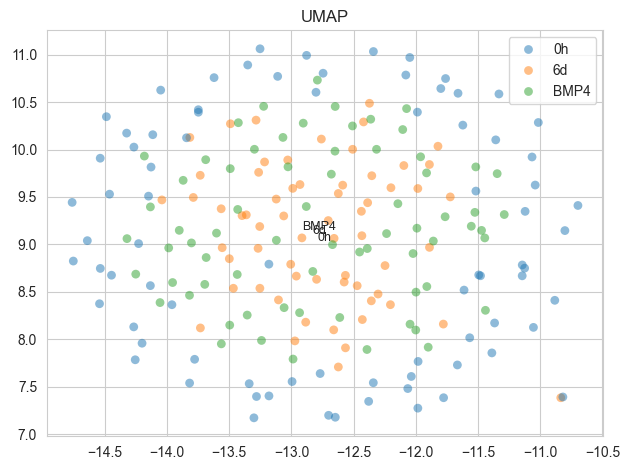

In [84]:
umap_visualize(Xp1, labels)